### Task 4 : Scaler Sensitivity Experiment

This notebook uses the Breast Cancer Prediction dataset to study the impact of feature scaling on machine learning models. It trains KNN and SVM classifiers on raw data and compares their performance after applying StandardScaler, MinMaxScaler, and RobustScaler. 
The notebook evaluates accuracy for all scaling approaches, introduces artificial outliers to test scaler robustness, and analyzes which scaling method performs best for real-world machine learning applications.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [2]:
### Load breast cancer dataset
dataset  = load_breast_cancer()

In [3]:

# Create dataframe from features
df = pd.DataFrame(
    dataset.data,
    columns=dataset.feature_names
)

# Add target column
df["target"] = dataset.target


print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
### Check basic information about dataset
# print(df.info())

print("\nMissing values:")
print(df.isnull().sum())


Missing values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [5]:
### Separate input features and target
X = df.drop(
    "target",
    axis=1
)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569,)


In [6]:
### Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


### Train KNN model on raw unscaled data

In [7]:
knn_raw = KNeighborsClassifier(
    n_neighbors=5
)

knn_raw.fit(
    X_train,
    y_train
)

KNeighborsClassifier()

In [8]:
# Prediction
y_pred_raw = knn_raw.predict(
    X_test
)

# Accuracy
knn_raw_accuracy = accuracy_score(
    y_test,
    y_pred_raw
)

print("KNN Accuracy on Raw Data:")
print(knn_raw_accuracy)

KNN Accuracy on Raw Data:
0.956140350877193


C:\Users\PM\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\PM\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\PM\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PM\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Use

### Train SVM model on raw unscaled data

In [9]:
from sklearn.svm import SVC

# Create SVM model
svm_raw = SVC()

# Train model
svm_raw.fit(
    X_train,
    y_train
)

# Prediction
y_pred_svm_raw = svm_raw.predict(
    X_test
)

# Accuracy
svm_raw_accuracy = accuracy_score(
    y_test,
    y_pred_svm_raw
)

print("SVM Accuracy on Raw Data:")
print(svm_raw_accuracy)

SVM Accuracy on Raw Data:
0.9473684210526315


### StandardScaler → KNN + SVM

In [10]:
### Apply StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform test data using same scaler
X_test_scaled = scaler.transform(
    X_test
)

In [11]:
### Train KNN on StandardScaled data
knn_standard = KNeighborsClassifier(
    n_neighbors=5
)

knn_standard.fit(
    X_train_scaled,
    y_train
)

# Prediction
y_pred_knn_standard = knn_standard.predict(
    X_test_scaled
)

# Accuracy
knn_standard_accuracy = accuracy_score(
    y_test,
    y_pred_knn_standard
)

print("KNN Accuracy with StandardScaler:")
print(knn_standard_accuracy)

KNN Accuracy with StandardScaler:
0.9473684210526315


In [12]:
### Train SVM on StandardScaled data
svm_standard = SVC()

svm_standard.fit(
    X_train_scaled,
    y_train
)

# Prediction
y_pred_svm_standard = svm_standard.predict(
    X_test_scaled
)

# Accuracy
svm_standard_accuracy = accuracy_score(
    y_test,
    y_pred_svm_standard
)

print("SVM Accuracy with StandardScaler:")
print(svm_standard_accuracy)

SVM Accuracy with StandardScaler:
0.9824561403508771


### MinMaxScaler → KNN + SVM

In [13]:
### Apply MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Create scaler
minmax_scaler = MinMaxScaler()

# Fit on training data and transform
X_train_minmax = minmax_scaler.fit_transform(
    X_train
)

# Transform test data
X_test_minmax = minmax_scaler.transform(
    X_test
)

In [14]:
### Train KNN on MinMaxScaled data
knn_minmax = KNeighborsClassifier(
    n_neighbors=5
)

knn_minmax.fit(
    X_train_minmax,
    y_train
)

# Prediction
y_pred_knn_minmax = knn_minmax.predict(
    X_test_minmax
)

# Accuracy
knn_minmax_accuracy = accuracy_score(
    y_test,
    y_pred_knn_minmax
)

print("KNN Accuracy with MinMaxScaler:")
print(knn_minmax_accuracy)

KNN Accuracy with MinMaxScaler:
0.9649122807017544


In [15]:
### Train SVM on MinMaxScaled data
svm_minmax = SVC()

svm_minmax.fit(
    X_train_minmax,
    y_train
)

# Prediction
y_pred_svm_minmax = svm_minmax.predict(
    X_test_minmax
)

# Accuracy
svm_minmax_accuracy = accuracy_score(
    y_test,
    y_pred_svm_minmax
)

print("SVM Accuracy with MinMaxScaler:")
print(svm_minmax_accuracy)

SVM Accuracy with MinMaxScaler:
0.9736842105263158


### RobustScaler → KNN + SVM

In [16]:
### Apply RobustScaler
from sklearn.preprocessing import RobustScaler

# Create scaler
robust_scaler = RobustScaler()

# Fit on training data
X_train_robust = robust_scaler.fit_transform(
    X_train
)

# Transform test data
X_test_robust = robust_scaler.transform(
    X_test
)

In [17]:
### Train KNN on RobustScaled data
knn_robust = KNeighborsClassifier(
    n_neighbors=5
)

knn_robust.fit(
    X_train_robust,
    y_train
)

# Prediction
y_pred_knn_robust = knn_robust.predict(
    X_test_robust
)

# Accuracy
knn_robust_accuracy = accuracy_score(
    y_test,
    y_pred_knn_robust
)

print("KNN Accuracy with RobustScaler:")
print(knn_robust_accuracy)

KNN Accuracy with RobustScaler:
0.956140350877193


In [18]:
### Train SVM on RobustScaled data
svm_robust = SVC()

svm_robust.fit(
    X_train_robust,
    y_train
)

# Prediction
y_pred_svm_robust = svm_robust.predict(
    X_test_robust
)

# Accuracy
svm_robust_accuracy = accuracy_score(
    y_test,
    y_pred_svm_robust
)

print("SVM Accuracy with RobustScaler:")
print(svm_robust_accuracy)

SVM Accuracy with RobustScaler:
0.9649122807017544


### Create results comparison table

In [19]:
results = pd.DataFrame({

    "Model": [
        "KNN",
        "SVM",
        "KNN",
        "SVM",
        "KNN",
        "SVM",
        "KNN",
        "SVM"
    ],

    "Scaler": [
        "Raw",
        "Raw",
        "StandardScaler",
        "StandardScaler",
        "MinMaxScaler",
        "MinMaxScaler",
        "RobustScaler",
        "RobustScaler"
    ],

    "Accuracy": [
        knn_raw_accuracy,
        svm_raw_accuracy,
        knn_standard_accuracy,
        svm_standard_accuracy,
        knn_minmax_accuracy,
        svm_minmax_accuracy,
        knn_robust_accuracy,
        svm_robust_accuracy
    ]
})

results

,Model,Scaler,Accuracy
0,KNN,Raw,0.956140
1,SVM,Raw,0.947368
2,KNN,StandardScaler,0.947368
3,SVM,StandardScaler,0.982456
4,KNN,MinMaxScaler,0.964912
5,SVM,MinMaxScaler,0.973684
6,KNN,RobustScaler,0.956140
7,SVM,RobustScaler,0.964912


## Inject 5 artificial outlier rows

In [20]:
### Inject 5 artificial outlier rows

# Copy original training data
X_train_outlier = X_train.copy()
y_train_outlier = y_train.copy()

# Create extreme values based on existing columns
outliers = X_train_outlier.sample(
    5,
    random_state=42
).copy()

# Make numerical values extremely large
for col in outliers.columns:
    outliers[col] = outliers[col] * 10

# Add outliers to training data
X_train_outlier = pd.concat(
    [
        X_train_outlier,
        outliers
    ],
    ignore_index=True
)


# Add corresponding target values
y_train_outlier = pd.concat(
    [
        y_train_outlier,
        y_train_outlier.sample(
            5,
            random_state=42
        )
    ],
    ignore_index=True
)


print("New training shape:")
print(X_train_outlier.shape)

New training shape:
(460, 30)


#### StandardScaler with outliers

In [21]:
standard_scaler_outlier = StandardScaler()

X_train_standard_outlier = standard_scaler_outlier.fit_transform(
    X_train_outlier
)

X_test_standard_outlier = standard_scaler_outlier.transform(
    X_test
)


knn_standard_outlier = KNeighborsClassifier(
    n_neighbors=5
)

knn_standard_outlier.fit(
    X_train_standard_outlier,
    y_train_outlier
)


knn_standard_outlier_acc = accuracy_score(
    y_test,
    knn_standard_outlier.predict(X_test_standard_outlier)
)


svm_standard_outlier = SVC()

svm_standard_outlier.fit(
    X_train_standard_outlier,
    y_train_outlier
)


svm_standard_outlier_acc = accuracy_score(
    y_test,
    svm_standard_outlier.predict(X_test_standard_outlier)
)


print("KNN StandardScaler:", knn_standard_outlier_acc)
print("SVM StandardScaler:", svm_standard_outlier_acc)

KNN StandardScaler: 0.9649122807017544
SVM StandardScaler: 0.956140350877193


#### MinMaxScaler with outliers

In [22]:
minmax_scaler_outlier = MinMaxScaler()

X_train_minmax_outlier = minmax_scaler_outlier.fit_transform(
    X_train_outlier
)

X_test_minmax_outlier = minmax_scaler_outlier.transform(
    X_test
)

knn_minmax_outlier = KNeighborsClassifier(
    n_neighbors=5
)

knn_minmax_outlier.fit(
    X_train_minmax_outlier,
    y_train_outlier
)

knn_minmax_outlier_acc = accuracy_score(
    y_test,
    knn_minmax_outlier.predict(X_test_minmax_outlier)
)

svm_minmax_outlier = SVC()

svm_minmax_outlier.fit(
    X_train_minmax_outlier,
    y_train_outlier
)

svm_minmax_outlier_acc = accuracy_score(
    y_test,
    svm_minmax_outlier.predict(X_test_minmax_outlier)
)

print("KNN MinMaxScaler:", knn_minmax_outlier_acc)
print("SVM MinMaxScaler:", svm_minmax_outlier_acc)

KNN MinMaxScaler:

 0.956140350877193
SVM MinMaxScaler: 0.956140350877193


#### RobustScaler with outliers

In [23]:
robust_scaler_outlier = RobustScaler()

X_train_robust_outlier = robust_scaler_outlier.fit_transform(
    X_train_outlier
)

X_test_robust_outlier = robust_scaler_outlier.transform(
    X_test
)


knn_robust_outlier = KNeighborsClassifier(
    n_neighbors=5
)

knn_robust_outlier.fit(
    X_train_robust_outlier,
    y_train_outlier
)


knn_robust_outlier_acc = accuracy_score(
    y_test,
    knn_robust_outlier.predict(X_test_robust_outlier)
)


svm_robust_outlier = SVC()

svm_robust_outlier.fit(
    X_train_robust_outlier,
    y_train_outlier
)

svm_robust_outlier_acc = accuracy_score(
    y_test,
    svm_robust_outlier.predict(X_test_robust_outlier)
)

print("KNN RobustScaler:", knn_robust_outlier_acc)
print("SVM RobustScaler:", svm_robust_outlier_acc)

KNN RobustScaler:

 0.956140350877193
SVM RobustScaler: 0.9736842105263158


In [24]:
outlier_results = pd.DataFrame({
    "Model": [
        "KNN",
        "SVM",
        "KNN",
        "SVM",
        "KNN",
        "SVM"
    ],

    "Scaler": [
        "StandardScaler",
        "StandardScaler",
        "MinMaxScaler",
        "MinMaxScaler",
        "RobustScaler",
        "RobustScaler"
    ],

    "Accuracy After Outliers": [
        knn_standard_outlier_acc,
        svm_standard_outlier_acc,
        knn_minmax_outlier_acc,
        svm_minmax_outlier_acc,
        knn_robust_outlier_acc,
        svm_robust_outlier_acc
    ]
})

outlier_results

,Model,Scaler,Accuracy After Outliers
0,KNN,StandardScaler,0.964912
1,SVM,StandardScaler,0.956140
2,KNN,MinMaxScaler,0.956140
3,SVM,MinMaxScaler,0.956140
4,KNN,RobustScaler,0.956140
5,SVM,RobustScaler,0.973684


Accuracy change after adding outliers

| Model | Scaler         | Before   | After    | Change     |
| ----- | -------------- | -------- | -------- | ---------- |
| KNN   | StandardScaler | 0.947368 | 0.964912 | +1.75%     |
| SVM   | StandardScaler | 0.982456 | 0.956140 | -2.63%     |
| KNN   | MinMaxScaler   | 0.964912 | 0.956140 | -0.88%     |
| SVM   | MinMaxScaler   | 0.973684 | 0.956140 | -1.75%     |
| KNN   | RobustScaler   | 0.956140 | 0.956140 | 0%         |
| SVM   | RobustScaler   | 0.964912 | 0.973684 | **+0.88%** |

Based on the results, the most robust scaler is RobustScaler, especially for SVM after adding outliers.

### Grouped Bar Chart

The chart below visualizes the 8 recorded accuracy results using grouped bars: each scaling method is shown on the x-axis, with separate bars for KNN and SVM.

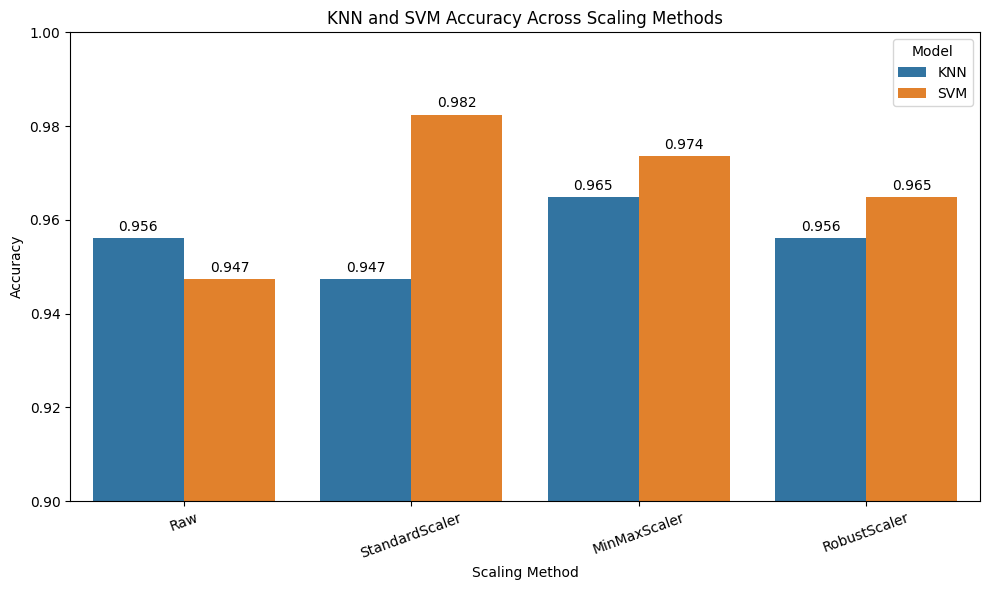

In [25]:
### Visualize all 8 model-scaler accuracy results
import matplotlib.pyplot as plt
import seaborn as sns

scaler_order = [
    "Raw",
    "StandardScaler",
    "MinMaxScaler",
    "RobustScaler"
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=results,
    x="Scaler",
    y="Accuracy",
    hue="Model",
    order=scaler_order,
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.title("KNN and SVM Accuracy Across Scaling Methods")
plt.xlabel("Scaling Method")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)
plt.xticks(rotation=20)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


#### Optional: Grouped Chart After Adding Outliers

This second chart shows the rerun results after artificial outliers were injected.

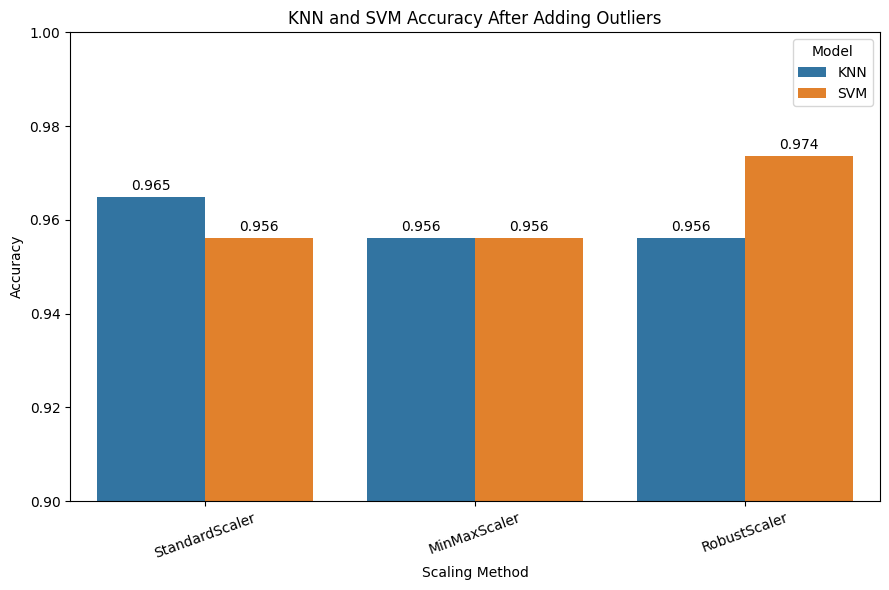

In [26]:
### Visualize accuracy after adding outliers
outlier_plot_data = outlier_results.rename(
    columns={"Accuracy After Outliers": "Accuracy"}
)

outlier_scaler_order = [
    "StandardScaler",
    "MinMaxScaler",
    "RobustScaler"
]

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=outlier_plot_data,
    x="Scaler",
    y="Accuracy",
    hue="Model",
    order=outlier_scaler_order,
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.title("KNN and SVM Accuracy After Adding Outliers")
plt.xlabel("Scaling Method")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)
plt.xticks(rotation=20)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


#### Before vs After Outlier Comparison

For robustness analysis, this comparison keeps model and scaler information separate instead of averaging KNN and SVM together.

In [27]:
### Prepare before-vs-after comparison data
comparison = pd.DataFrame({
    "Model": [
        "KNN",
        "SVM",
        "KNN",
        "SVM",
        "KNN",
        "SVM"
    ],

    "Scaler": [
        "StandardScaler",
        "StandardScaler",
        "MinMaxScaler",
        "MinMaxScaler",
        "RobustScaler",
        "RobustScaler"
    ],

    "Before Outliers": [
        knn_standard_accuracy,
        svm_standard_accuracy,
        knn_minmax_accuracy,
        svm_minmax_accuracy,
        knn_robust_accuracy,
        svm_robust_accuracy
    ],

    "After Outliers": [
        knn_standard_outlier_acc,
        svm_standard_outlier_acc,
        knn_minmax_outlier_acc,
        svm_minmax_outlier_acc,
        knn_robust_outlier_acc,
        svm_robust_outlier_acc
    ]
})

plot_data = comparison.melt(
    id_vars=["Model", "Scaler"],
    value_vars=[
        "Before Outliers",
        "After Outliers"
    ],
    var_name="Condition",
    value_name="Accuracy"
)

plot_data


,Model,Scaler,Condition,Accuracy
0,KNN,StandardScaler,Before Outliers,0.947368
1,SVM,StandardScaler,Before Outliers,0.982456
2,KNN,MinMaxScaler,Before Outliers,0.964912
3,SVM,MinMaxScaler,Before Outliers,0.973684
4,KNN,RobustScaler,Before Outliers,0.956140
5,SVM,RobustScaler,Before Outliers,0.964912
6,KNN,StandardScaler,After Outliers,0.964912
7,SVM,StandardScaler,After Outliers,0.956140
8,KNN,MinMaxScaler,After Outliers,0.956140
9,SVM,MinMaxScaler,After Outliers,0.956140


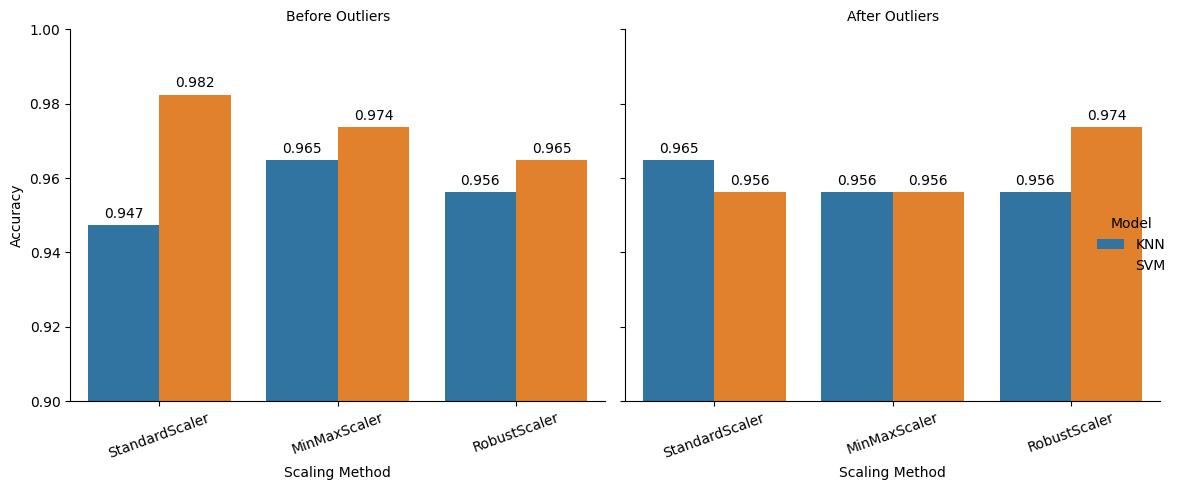

In [28]:
### Faceted grouped bar chart before and after outliers
g = sns.catplot(
    data=plot_data,
    kind="bar",
    x="Scaler",
    y="Accuracy",
    hue="Model",
    col="Condition",
    order=outlier_scaler_order,
    errorbar=None,
    height=5,
    aspect=1.1
)

g.set_axis_labels("Scaling Method", "Accuracy")
g.set_titles("{col_name}")
g.set(ylim=(0.90, 1.00))

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=3
        )

plt.tight_layout()
plt.show()


### Conclusion

The experiment shows that scaling has a significant impact on distance-based models such as KNN and SVM.
Before adding outliers, StandardScaler produced the highest accuracy, especially with SVM.
However, after introducing artificial outliers, RobustScaler showed better stability because it uses median and IQR, making it less sensitive to extreme values. 
This demonstrates that the choice of scaler depends on the dataset characteristics. 
In practical machine learning projects, StandardScaler is a good default choice for normally distributed data, while RobustScaler is preferred when the dataset contains significant outliers.